In [597]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [598]:
sales_df = pd.read_csv("/Users/athipongjindaphram/Documents/E-Commerce_Product_Intelligence_Project/data/sales_analytics.csv")
reviews = pd.read_csv("/Users/athipongjindaphram/Documents/E-Commerce_Product_Intelligence_Project/data/reviews.csv")
sessions = pd.read_csv("/Users/athipongjindaphram/Documents/E-Commerce_Product_Intelligence_Project/data/sessions.csv")
interactions = pd.read_csv("/Users/athipongjindaphram/Documents/E-Commerce_Product_Intelligence_Project/data/interactions.csv")
purchases = pd.read_csv("/Users/athipongjindaphram/Documents/E-Commerce_Product_Intelligence_Project/data/purchases.csv")

In [599]:
sales_df.sample(5)

,order_date,order_month,user_id,gender,country,loyalty_tier,age_group,product_id,product_name,category,brand,price_segment,quantity,total_amount
689,2024-10-23 10:26:16.537965798,2024-10,47a8baa9-5362-4d35-b8ce-40a8def30aa8,Female,MX,bronze,26-35,5d07bcd4-3670-4a0d-91f6-e36d7d335597,Adidas Sterling Silver Jewelry,Clothing & Accessories,Adidas,Medium,1,26.93
1366,2025-11-01 22:41:25.892201468,2025-11,72d7f79e-be21-4b18-87ec-8527dbd44901,Male,BR,platinum,18-25,d3701c21-709a-4090-bab2-020261ce8a92,Cuisinart Smart Appliance,Home & Kitchen,Cuisinart,High,1,45.42
226,2023-10-06 21:49:12.427906868,2023-10,90c49c36-19e2-49d8-af1b-3357d9b377c3,Female,NO,bronze,36-45,71445abc-2f0d-4ac2-8097-acb7a3823bc9,Wilson Cycling - Navy,Sports & Outdoors,Wilson,High,1,35.98
1445,2025-12-26 16:16:27.598714582,2025-12,1fc911b3-7429-46dd-9b91-77dc111d50cc,Female,US,bronze,36-45,6d7c422e-e9bc-432a-98f7-7c8829437f0b,Cuisinart Modern Home Decor,Home & Kitchen,Cuisinart,Medium,1,35.35
1312,2025-09-29 22:06:30.516886844,2025-09,2659a397-771d-467c-8cc9-7ff6f3d22ca3,Male,US,bronze,18-25,88f38eae-9124-4557-a285-248fc1cad30c,Nestle Pantry Staple Multipack,Grocery & Gourmet,Nestle,Low,1,7.71


# Customer Analysis

#### 1. Who are our Customers?
#### 2. Which age group dominates?
#### 3. Which loyalty tier is largest?

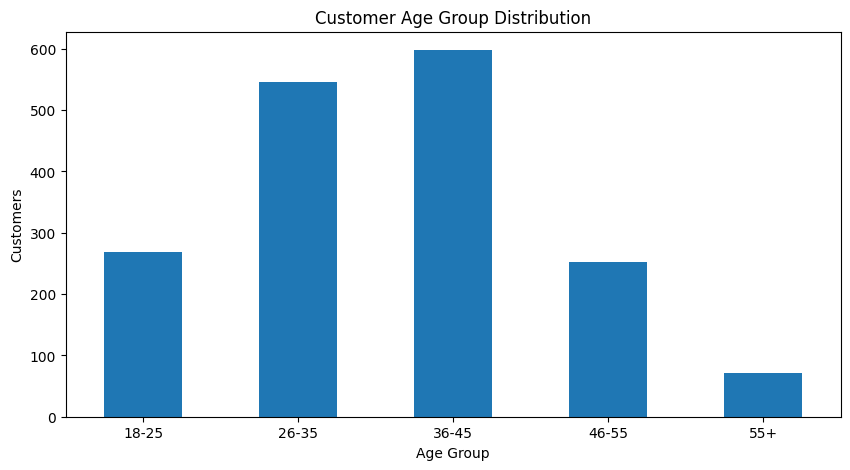

In [600]:
# Age group distribution

plt.figure(figsize=(10,5))

sales_df["age_group"].value_counts().sort_index().plot(kind="bar")

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.ylabel("Customers")

plt.show()

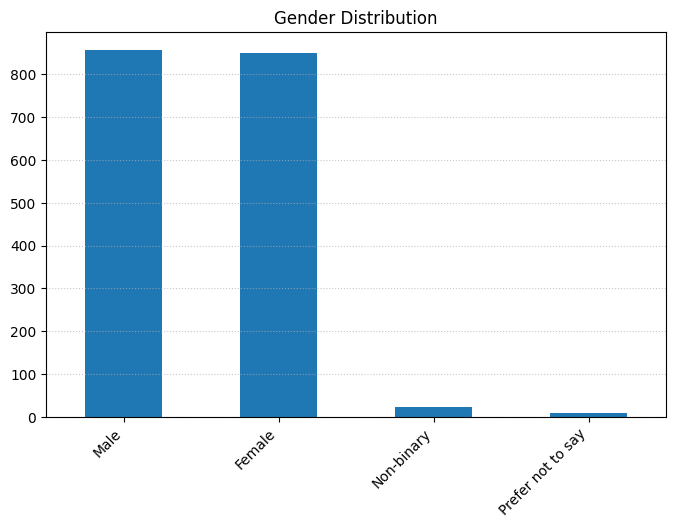

In [601]:
# Gender Distribution

plt.figure(figsize=(8,5))

sales_df["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.7, linestyle=":")
plt.show()

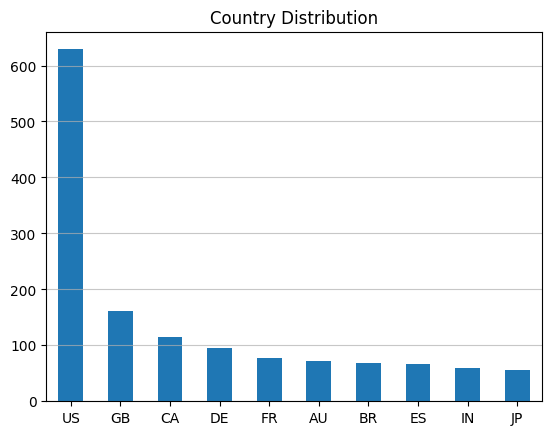

In [602]:
# Country Distribution

sales_df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Country Distribution")
plt.xticks(rotation=0)
plt.grid(alpha=0.7, axis="y")
plt.show()


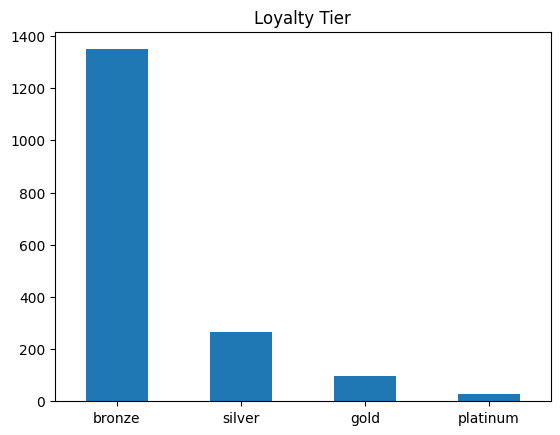

In [603]:
# Loyalty tier

sales_df["loyalty_tier"].value_counts().plot(kind="bar")
plt.title("Loyalty Tier")
plt.xticks(rotation=0)
plt.show()

# Product Analysis

#### 1. Which categories have the most products?
#### 2. Are products concentrated in low-price segments?
#### 3. Which brands dominate the catalog?

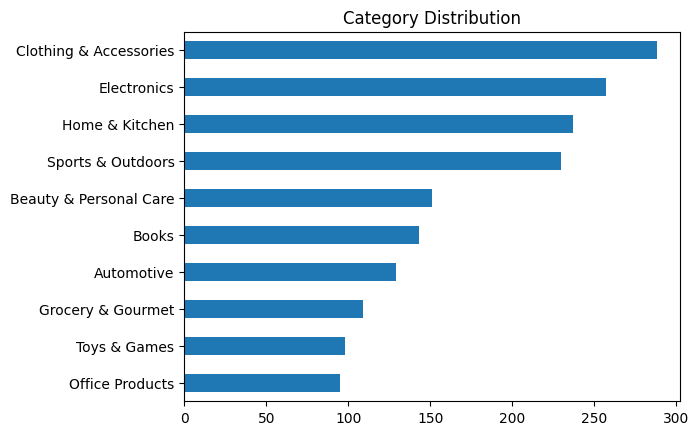

In [604]:
# Category Distribution

ax = sales_df["category"].value_counts().head(10).plot(kind="barh")
ax.invert_yaxis()
ax.set_title("Category Distribution")
plt.show()


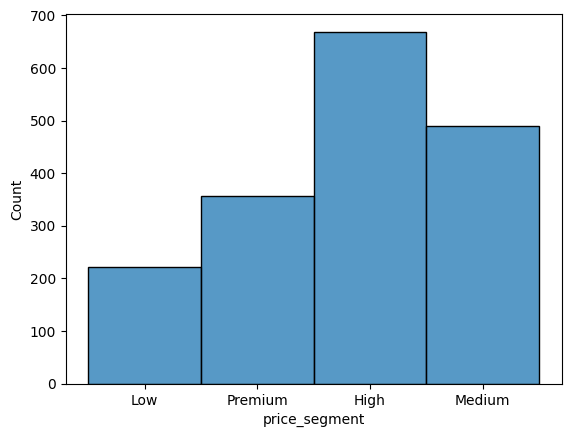

In [605]:
# Price Distribution

sns.histplot(
    sales_df["price_segment"],
    bins=30
)
plt.show()

In [606]:
# Brand Distribution

sales_df["brand"].value_counts().head(10)

Apple            181
Wilson           146
Nike             132
Adidas            79
Neutrogena        74
Cuisinart         73
Penguin Books     71
LEGO              67
Instant Pot       66
Nestle            59
Name: brand, dtype: int64

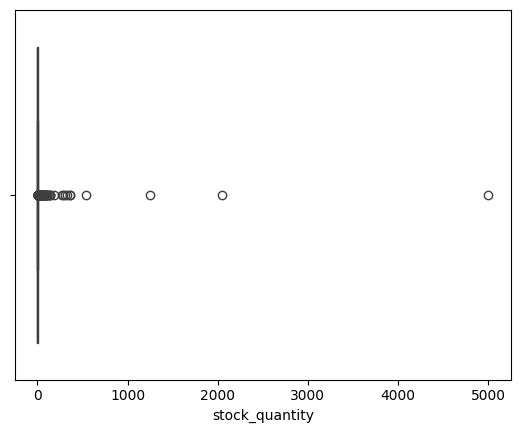

In [607]:
df_products = pd.read_csv("/Users/athipongjindaphram/Documents/E-Commerce_Product_Intelligence_Project/data/products.csv")

sns.boxplot(
    x = df_products["stock_quantity"]
)
plt.show()

# Revenue Analysis

#### 1. Where does revenue come from?
#### 2. Which category generates the most revenue?
#### 3. Who are the highest-value customers?

In [608]:
# Total Revenue

sales_df["total_amount"].sum()

129510.84999999999

In [609]:
# Monthly Revenue

monthly_revenue = (
    sales_df
    .groupby("order_month")
    ["total_amount"]
    .sum()
)

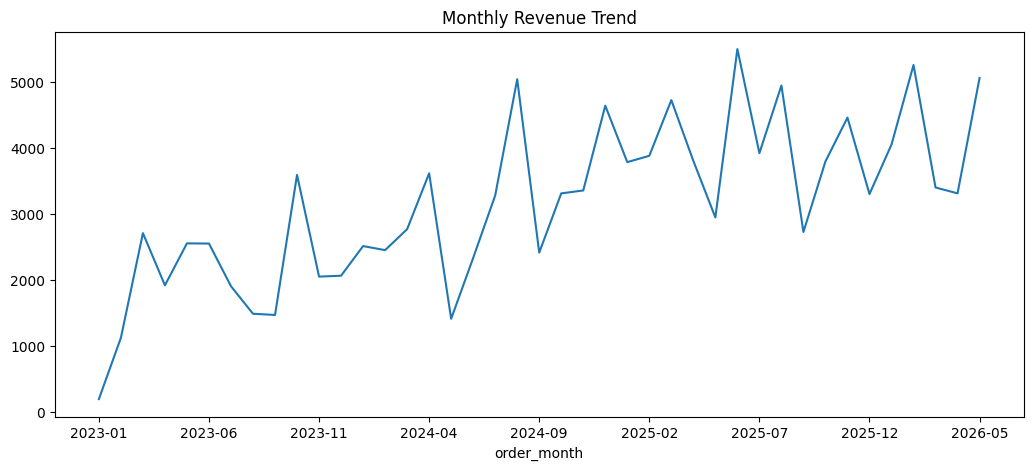

In [610]:
# Revenue Trend

monthly_revenue.plot(
    figsize=(12.5, 5)
)

plt.title("Monthly Revenue Trend")
plt.show()

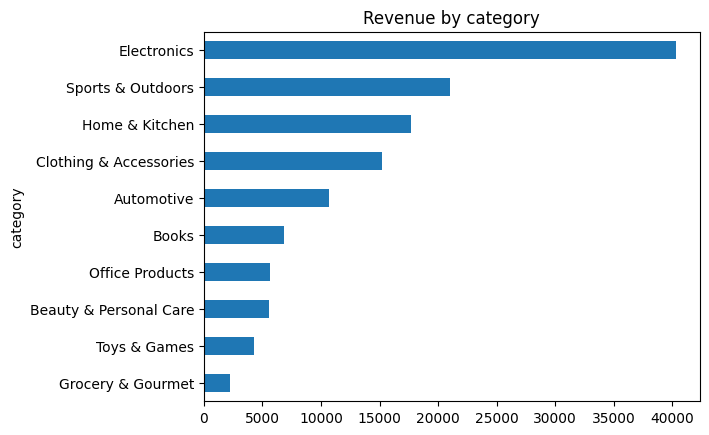

In [611]:
# Revenue by category

ax = sales_df.groupby("category")["total_amount"].sum().sort_values(ascending=False).head(10).plot(kind="barh")
ax.invert_yaxis()
ax.set_title("Revenue by category")
plt.show()


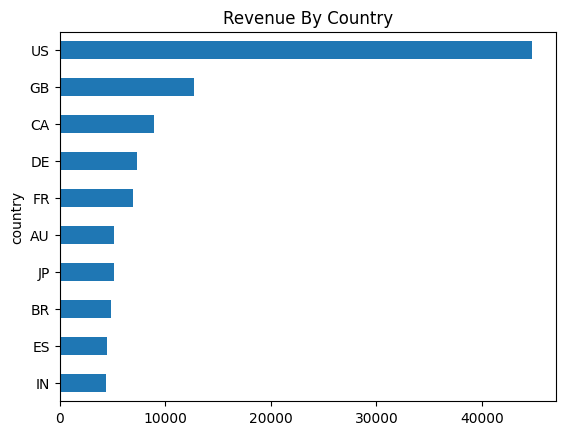

In [612]:
# Revenue By Country

ax = sales_df.groupby("country")["total_amount"].sum().sort_values(ascending=False).head(10).plot(kind="barh")
ax.invert_yaxis()
ax.set_title("Revenue By Country")
plt.show()

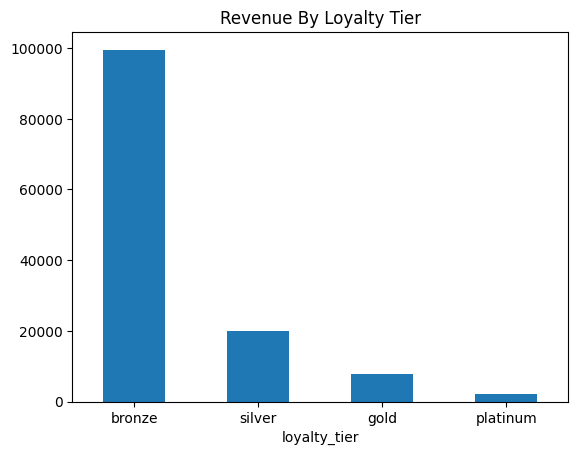

In [613]:
# Revenue By Loyalty Tier

sales_df.groupby("loyalty_tier")["total_amount"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Revenue By Loyalty Tier")
plt.xticks(rotation=0)
plt.show()


In [614]:
# Top 10 Products

sales_df.groupby("product_name")["total_amount"].sum().sort_values(ascending=False).head(10)

product_name
Apple Accessorie Stand                8459.40
Apple Book4 Ultrabook                 7202.93
Wilson Book19 Fitness Equipment       5883.08
Instant Pot Microfiber Kitchenware    5218.45
Wilson Fitness Equipment Pro          3471.85
Castrol Prime7 Electronic             2791.99
Tommy Hilfiger Womenswear Dress       2503.33
Cuisinart Smart Appliance             2363.42
Nike Womenswear in Olive              2170.90
Apple Ultra Prime3                    2146.77
Name: total_amount, dtype: float64

# Review Analysis

#### 1. Do popular products have better ratings?
#### 2. Which categories have customer satisfaction issues?

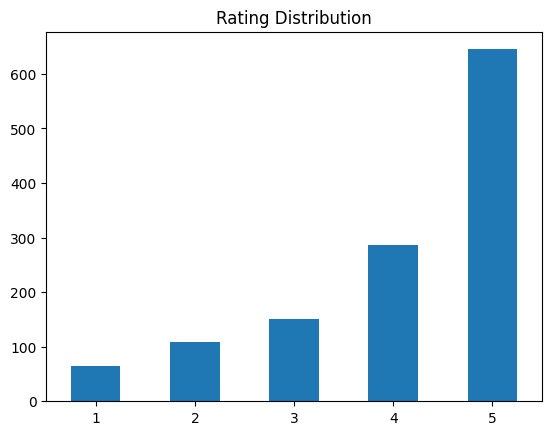

In [615]:
# Rating Distribution

reviews["rating"].value_counts().sort_index().plot(kind="bar")
plt.xticks(rotation=0)
plt.title("Rating Distribution")
plt.show()

In [616]:
# Average Rating By Category

review_df = reviews.merge(
    df_products,
    on="product_id"
)

review_df.groupby("category")["rating"].mean().sort_values(ascending=False)

category
Electronics               4.174603
Home & Kitchen            4.161850
Toys & Games              4.089744
Books                     4.067227
Grocery & Gourmet         4.054795
Sports & Outdoors         4.050000
Automotive                4.049383
Beauty & Personal Care    4.030303
Office Products           4.014085
Clothing & Accessories    3.957143
Name: rating, dtype: float64

In [617]:
# Most Review Products

review_df.groupby("product_name")["rating"].count().sort_values(ascending=False).head(10)

product_name
Apple Accessorie Stand                        54
Wilson Fitness Equipment Pro                  37
The Data Structures: A Comprehensive Guide    28
Instant Pot Microfiber Kitchenware            28
Cuisinart Smart Appliance                     27
Post-it Premium Stationery Set                26
Adidas Sterling Silver Jewelry                24
Neutrogena Bath & Body Lotion                 22
Nestle Pantry Staple Multipack                22
Wilson Book19 Fitness Equipment               21
Name: rating, dtype: int64

# Funnel Analysis

#### 1. Where are customers dropping off?
#### 2. How efficient is the purchase journey?

In [618]:
# Sessions

sessions_count = len(sessions)
sessions_count

19315

In [619]:
# Interactions

interactions_count = len(interactions)
interactions_count

100000

In [620]:
# Purchases

purchases_count = len(purchases)
purchases_count

1737

In [621]:
# Funnel Table

funnel = pd.DataFrame({
    "Stage" : [
        "Sessions",
        "Interactions",
        "Purchases"
    ],
    "Count" : [
        sessions_count,
        interactions_count,
        purchases_count
    ]
})

funnel

,Stage,Count
0,Sessions,19315
1,Interactions,100000
2,Purchases,1737


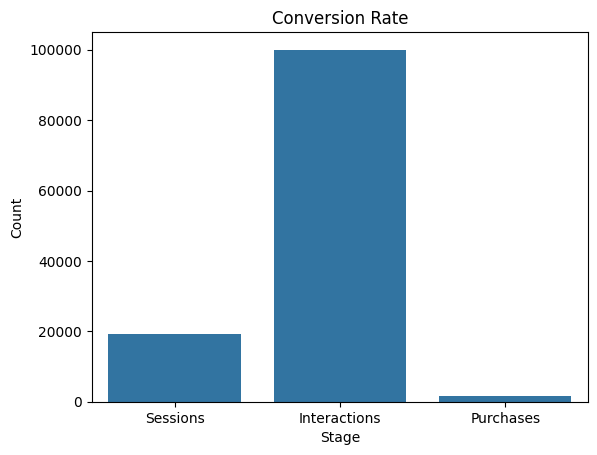

In [622]:
# Funnel Chart

sns.barplot(
    data=funnel,
    x="Stage",
    y="Count"
)

plt.title("Conversion Rate")
plt.show()

In [623]:
# Conversion Rate

purchase_rate = (
    purchases_count / sessions_count
) * 100

print(f"Conversion Rate : {purchase_rate:.2f}%")

Conversion Rate : 8.99%


# Business Insight Summary

## Executive Summary

This analysis provides a comprehensive overview of customer behavior, product performance, purchasing patterns, and conversion efficiency using an e-commerce transactional dataset.

Overall, the business demonstrates healthy customer engagement and consistent purchasing activity. Revenue is primarily generated from a limited number of product categories and high-value customers, suggesting that sales are concentrated rather than evenly distributed across the entire customer base.

Customer purchasing behavior indicates opportunities to improve conversion efficiency, increase customer retention, and maximize long-term customer value through data-driven marketing strategies.

## Customer Insights

The customer base is dominated by a specific age segment, indicating a clear target demographic for future marketing campaigns.

Customer spending varies significantly across loyalty tiers, with higher-tier members contributing a disproportionately larger share of total revenue. This suggests that customer retention initiatives may provide greater business value than focusing solely on acquiring new customers.

Geographical analysis also reveals that revenue is concentrated in several key markets, presenting opportunities for localized promotions and regional business expansion.

## Product Insights

Sales performance is heavily concentrated within a small number of product categories and best-selling products.

This indicates that customer demand is not evenly distributed across the product catalog. High-performing products should receive priority in inventory management, promotional campaigns, and product availability to prevent stock shortages.

Meanwhile, lower-performing categories may require pricing adjustments, promotional activities, or portfolio optimization to improve their contribution to overall revenue.

## Revenue Insights

Revenue trends demonstrate overall business performance throughout the analysis period.

Monthly sales patterns may indicate seasonal demand or promotional effects, highlighting the importance of monitoring revenue fluctuations over time.

Average order value provides additional insight into customer purchasing behavior and can be used to evaluate the effectiveness of pricing strategies and cross-selling opportunities.

## Customer Satisfaction Insights

Customer ratings provide valuable feedback regarding product quality and customer experience.

Products with consistently higher ratings tend to receive stronger customer engagement, suggesting that positive customer experiences contribute to sustained product performance.

Products with relatively low ratings should be investigated further to identify potential quality or service issues that may negatively impact future sales.

## Conversion Funnel Insights

The customer journey reveals noticeable drop-off between browsing activities and completed purchases.

This suggests that while customers actively interact with products, a significant proportion do not complete the purchasing process.

Potential factors may include checkout complexity, pricing concerns, shipping costs, or overall user experience. Improving these stages could increase conversion rates and overall business performance.

## Executive Business Insights

Based on the overall analysis, several key business findings have been identified:

• Customer revenue is concentrated among a relatively small group of high-value customers.

• A limited number of product categories generate the majority of total revenue.

• Customer loyalty appears to have a strong relationship with purchasing behavior, indicating opportunities for personalized marketing campaigns.

• Product ratings suggest that customer satisfaction may influence future purchasing decisions.

• The conversion funnel indicates opportunities to optimize the purchasing journey and reduce customer drop-off before checkout.

Overall, the business has a strong foundation for growth. Future initiatives should focus on customer retention, conversion optimization, inventory planning, and personalized marketing to maximize long-term profitability.

## Business Recommendations

1. Strengthen customer retention by offering personalized rewards and exclusive promotions to high-value customers.

2. Increase marketing investment in top-performing product categories while continuously monitoring inventory availability.

3. Optimize the purchase journey by simplifying the checkout process and reducing barriers to conversion.

4. Expand business opportunities within high-performing geographic markets through localized campaigns.

5. Monitor customer feedback regularly and prioritize improvements for products with consistently low ratings.

6. Utilize customer segmentation techniques such as RFM analysis to support personalized marketing and customer lifetime value optimization.